In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import cv2
from collections import Counter
from skimage.color import rgb2lab, deltaE_cie76
import os

%matplotlib inline


In [2]:
def get_image(image_path):
    image = cv2.imread(image_path)
    #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image
def RGB2HEX(color):
    return "#{:02x}{:02x}{:02x}".format(int(color[0]), int(color[1]), int(color[2]))

In [3]:
image = get_image('./image_eye.jpg')
height, width, channels = image.shape 
print(height, width)
image = image[0:100, 80:170]
height, width, channels = image.shape 
print(height, width)
modified_image = image
cv2.imshow("image", image)
cv2.waitKey(0)

1999 1500
100 90


QFontDatabase: Cannot find font directory /home/yeezy/miniconda3/envs/pc/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yeezy/miniconda3/envs/pc/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yeezy/miniconda3/envs/pc/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yeezy/miniconda3/envs/pc/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font director

-1

In [4]:
# modified_image = cv2.resize(image, (600, 400), interpolation = cv2.INTER_AREA)
modified_image = modified_image.reshape(modified_image.shape[0]*modified_image.shape[1], 3)
# cv2.imshow("mod",modified_image)
# cv2.waitKey(0)

In [5]:
clf = KMeans(n_clusters = 8)
labels = clf.fit_predict(modified_image)

([<matplotlib.patches.Wedge at 0x7f9961535f00>,
 [Text(1.0944845886871881, 0.11001584034236578, '#e4e1dd'),
  Text(1.0504649933536154, 0.32637907061971533, '#e5e2de'),
  Text(-1.0725791664390796, 0.24407771655939664, '#e2dfdb'),
  Text(0.9078417834161316, -0.6211467590544266, '#e3e0dc'),
  Text(1.0735084631827065, -0.23995745346853367, '#e6e3df'),
  Text(1.0974265321865295, -0.07519977694812911, '#e7e4e0'),
  Text(1.0993564468820165, -0.037621838059138504, '#e8e5e1'),
  Text(1.0999396875798344, -0.011518840513539413, '#e0ddd9')])

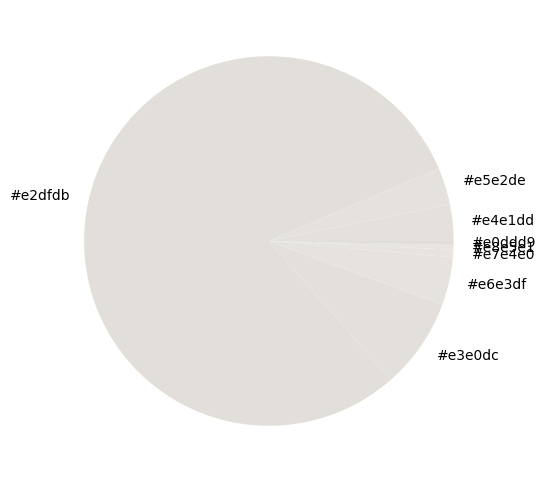

In [6]:
counts = Counter(labels)
center_colors = clf.cluster_centers_

ordered_colors = [center_colors[i] for i in counts.keys()]
hex_colors = [RGB2HEX(ordered_colors[i]) for i in counts.keys()]
rgb_colors = [ordered_colors[i] for i in counts.keys()]

plt.figure(figsize = (8,6))
plt.pie(counts.values(), labels = hex_colors, colors = hex_colors)

In [7]:
print(rgb_colors)

[array([228., 225., 221.]), array([229., 226., 222.]), array([226., 223., 219.]), array([227., 224., 220.]), array([230., 227., 223.]), array([231., 228., 224.]), array([232.76666667, 229.76666667, 225.76666667]), array([224.35, 221.35, 217.35])]


In [8]:
# !pip install webcolors
import webcolors

color_names = []
def closest_colour(requested_colour):
    min_colours = {}
    for key, name in webcolors.CSS3_HEX_TO_NAMES.items():
        r_c, g_c, b_c = webcolors.hex_to_rgb(key)
        rd = (r_c - requested_colour[0]) ** 2
        gd = (g_c - requested_colour[1]) ** 2
        bd = (b_c - requested_colour[2]) ** 2
        min_colours[(rd + gd + bd)] = name
    return min_colours[min(min_colours.keys())]

def get_colour_name(requested_colour):
    try:
        closest_name = actual_name = webcolors.rgb_to_name(requested_colour)
    except ValueError:
        closest_name = closest_colour(requested_colour)
        actual_name = None
    return actual_name, closest_name

for i in rgb_colors:
    requested_colour = [i[0], i[1], i[2]]
    actual_name, closest_name = get_colour_name(requested_colour)
    if (actual_name != None):
        color_names.append(actual_name)
    else:
        color_names.append(closest_name)

print(color_names)

AttributeError: module 'webcolors' has no attribute 'CSS3_HEX_TO_NAMES'